In [1]:
# 1. Kết nối với Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# 2. Giải nén dữ liệu từ Google Drive vào ổ cứng cục bộ của Colab
# Lưu ý: Đường dẫn ZIP_PATH này giả định bạn ném file ZIP thẳng vào thư mục gốc của My Drive
import os

ZIP_PATH = '/content/drive/MyDrive/SisFall_dataset_Windowed.zip'
EXTRACT_PATH = '/content/SisFall_dataset_Windowed'

if not os.path.exists(EXTRACT_PATH):
    print("Đang giải nén dữ liệu...")
    !7z x "$ZIP_PATH" -o/content/ > /dev/null
    print("Giải nén hoàn tất!")
else:
    print("Thư mục đã được giải nén sẵn!")

Đang giải nén dữ liệu...
Giải nén hoàn tất!


In [5]:
# 3. Khai báo thư viện
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print("TensorFlow Version:", tf.__version__)

# Kiểm tra GPU
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
  print("[*] Đang sử dụng GPU:", gpu_devices)
else:
  print("[*] Cảnh báo: Đang chạy bằng CPU!")

TensorFlow Version: 2.20.0
[*] Đang sử dụng GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# 4. Cấu hình biến môi trường và LSO
DATA_DIR = Path(EXTRACT_PATH)

LABEL_MAP = {
    'D01': 0, 'D02': 0, 'D05': 0, 'D06': 0, 'D19': 0,
    'D03': 1, 'D04': 1,
    'D07': 2, 'D08': 2, 'D09': 2, 'D10': 2, 'D11': 2, 'D12': 2, 'D13': 2, 'D14': 2, 'D15': 2, 'D16': 2, 'D17': 2, 'D18': 2,
    'F01': 3, 'F02': 3, 'F03': 3, 'F04': 3, 'F05': 3, 'F06': 3, 'F07': 3, 'F08': 3, 'F09': 3,
    'F10': 3, 'F11': 3, 'F12': 3, 'F13': 3, 'F14': 3, 'F15': 3
}
CLASS_NAMES = ['Walk', 'Run', 'Static/ADL', 'Fall']

# Chia tập Leave-Subjects-Out
TRAIN_SUBJECTS = {f"SA{i:02d}" for i in range(1, 19)} | {f"SE{i:02d}" for i in range(1, 9)}
VAL_SUBJECTS = {f"SA{i:02d}" for i in range(19, 22)} | {f"SE{i:02d}" for i in range(9, 12)}
TEST_SUBJECTS = {f"SA{i:02d}" for i in range(22, 24)} | {f"SE{i:02d}" for i in range(12, 16)}

In [10]:
from pathlib import Path

# ============================================================
# TÌM THƯ MỤC DATASET
# ============================================================

CONTENT_DIR = Path("/content")
DATASET_DIR_NAME = "SisFall_dataset_Windowed"

matches = [
    path
    for path in CONTENT_DIR.rglob(DATASET_DIR_NAME)
    if path.is_dir()
]

print(f"Tìm thấy {len(matches)} thư mục '{DATASET_DIR_NAME}':")

for path in matches:
    print(f"  - {path}")

# Không tìm thấy dataset
if not matches:
    raise FileNotFoundError(
        f"Không tìm thấy thư mục '{DATASET_DIR_NAME}' trong {CONTENT_DIR}.\n"
        "Hãy kiểm tra dataset đã được giải nén đúng chưa."
    )

# Nếu tìm thấy nhiều thư mục, mặc định lấy thư mục đầu tiên
DATA_DIR = matches[0]

# ============================================================
# KIỂM TRA FILE CSV
# ============================================================

csv_files = sorted(DATA_DIR.rglob("*.csv"))

if not csv_files:
    raise RuntimeError(
        f"Đã tìm thấy dataset tại:\n{DATA_DIR}\n"
        "nhưng không tìm thấy file CSV nào."
    )

# ============================================================
# HIỂN THỊ THÔNG TIN
# ============================================================

print("\nDataset đã sẵn sàng.")
print(f"DATA_DIR    : {DATA_DIR}")
print(f"Số file CSV: {len(csv_files)}")

print("\nMột số file mẫu:")
for file in csv_files[:5]:
    print(f"  - {file}")

Tìm thấy 1 thư mục 'SisFall_dataset_Windowed':
  - /content/sis_fall_har_and_fall-detection_trainning-main/SisFall_dataset_Windowed

Dataset đã sẵn sàng.
DATA_DIR    : /content/sis_fall_har_and_fall-detection_trainning-main/SisFall_dataset_Windowed
Số file CSV: 105501

Một số file mẫu:
  - /content/sis_fall_har_and_fall-detection_trainning-main/SisFall_dataset_Windowed/SA01/D01_SA01_R01_W000.csv
  - /content/sis_fall_har_and_fall-detection_trainning-main/SisFall_dataset_Windowed/SA01/D01_SA01_R01_W001.csv
  - /content/sis_fall_har_and_fall-detection_trainning-main/SisFall_dataset_Windowed/SA01/D01_SA01_R01_W002.csv
  - /content/sis_fall_har_and_fall-detection_trainning-main/SisFall_dataset_Windowed/SA01/D01_SA01_R01_W003.csv
  - /content/sis_fall_har_and_fall-detection_trainning-main/SisFall_dataset_Windowed/SA01/D01_SA01_R01_W004.csv


In [11]:
!pip install -q scikit-learn seaborn

In [12]:
from pathlib import Path

# ============================================================
# DATASET CONFIG
# ============================================================

DATA_DIR = Path(
    "/content/sis_fall_har_and_fall-detection_trainning-main/"
    "SisFall_dataset_Windowed"
)

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Không tìm thấy dataset tại:\n{DATA_DIR}"
    )

all_files = sorted(DATA_DIR.rglob("*.csv"))

print("DATA_DIR :", DATA_DIR)
print("Total CSV:", len(all_files))

EXPECTED_FILES = 105_501

if len(all_files) != EXPECTED_FILES:
    raise RuntimeError(
        f"Số lượng CSV không đúng.\n"
        f"Expected: {EXPECTED_FILES}\n"
        f"Actual  : {len(all_files)}"
    )

print("Dataset OK.")

DATA_DIR : /content/sis_fall_har_and_fall-detection_trainning-main/SisFall_dataset_Windowed
Total CSV: 105501
Dataset OK.


In [13]:
# ============================================================
# LABEL CONFIG
# ============================================================

LABEL_MAP = {
    # Walk
    "D01": 0,
    "D02": 0,
    "D05": 0,
    "D06": 0,
    "D19": 0,

    # Run
    "D03": 1,
    "D04": 1,

    # Static / ADL
    "D07": 2,
    "D08": 2,
    "D09": 2,
    "D10": 2,
    "D11": 2,
    "D12": 2,
    "D13": 2,
    "D14": 2,
    "D15": 2,
    "D16": 2,
    "D17": 2,
    "D18": 2,

    # Fall
    "F01": 3,
    "F02": 3,
    "F03": 3,
    "F04": 3,
    "F05": 3,
    "F06": 3,
    "F07": 3,
    "F08": 3,
    "F09": 3,
    "F10": 3,
    "F11": 3,
    "F12": 3,
    "F13": 3,
    "F14": 3,
    "F15": 3,
}

CLASS_NAMES = [
    "Walk",
    "Run",
    "Static/ADL",
    "Fall",
]

NUM_CLASSES = len(CLASS_NAMES)

# 6 tín hiệu đầu vào
REQUIRED_COLUMNS = [
    "ADXL_X",
    "ADXL_Y",
    "ADXL_Z",
    "ITG_X",
    "ITG_Y",
    "ITG_Z",
]

WINDOW_SIZE = 200
NUM_FEATURES = len(REQUIRED_COLUMNS)


# ============================================================
# LEAVE-SUBJECTS-OUT SPLIT
# ============================================================

TRAIN_SUBJECTS = (
    {f"SA{i:02d}" for i in range(1, 19)}
    | {f"SE{i:02d}" for i in range(1, 9)}
)

VAL_SUBJECTS = (
    {f"SA{i:02d}" for i in range(19, 22)}
    | {f"SE{i:02d}" for i in range(9, 12)}
)

TEST_SUBJECTS = (
    {f"SA{i:02d}" for i in range(22, 24)}
    | {f"SE{i:02d}" for i in range(12, 16)}
)


# ============================================================
# VALIDATION
# ============================================================

assert TRAIN_SUBJECTS.isdisjoint(VAL_SUBJECTS)
assert TRAIN_SUBJECTS.isdisjoint(TEST_SUBJECTS)
assert VAL_SUBJECTS.isdisjoint(TEST_SUBJECTS)

print("Train subjects:", len(TRAIN_SUBJECTS))
print("Val subjects  :", len(VAL_SUBJECTS))
print("Test subjects :", len(TEST_SUBJECTS))

print("\nInput shape:")
print(f"({WINDOW_SIZE}, {NUM_FEATURES})")

print("\nClasses:")
for index, name in enumerate(CLASS_NAMES):
    print(index, "->", name)

Train subjects: 26
Val subjects  : 6
Test subjects : 6

Input shape:
(200, 6)

Classes:
0 -> Walk
1 -> Run
2 -> Static/ADL
3 -> Fall


In [15]:
import numpy as np
import pandas as pd

from concurrent.futures import ThreadPoolExecutor


# ============================================================
# LOAD ONE CSV
# ============================================================

def load_single_csv(file_path):
    try:
        # Ví dụ:
        # D01_SA01_...
        # F03_SE05_...

        parts = file_path.stem.split("_")

        if len(parts) < 2:
            return None

        label_code = parts[0]
        subject_id = parts[1]

        # Nhãn không sử dụng
        if label_code not in LABEL_MAP:
            return None

        # Subject không thuộc tập nào
        if (
            subject_id not in TRAIN_SUBJECTS
            and subject_id not in VAL_SUBJECTS
            and subject_id not in TEST_SUBJECTS
        ):
            return None

        df = pd.read_csv(file_path)

        # Mỗi window phải có đúng 200 sample
        if len(df) != WINDOW_SIZE:
            return None

        # Kiểm tra đủ 6 sensor channels
        missing_columns = [
            col
            for col in REQUIRED_COLUMNS
            if col not in df.columns
        ]

        if missing_columns:
            return None

        data = df[REQUIRED_COLUMNS].to_numpy(
            dtype=np.float32
        )

        label = LABEL_MAP[label_code]

        return data, label, subject_id

    except Exception:
        return None

In [16]:
# ============================================================
# PREPARE DATASET
# ============================================================

def prepare_dataset(max_workers=16):

    X_train_list = []
    y_train_list = []

    X_val_list = []
    y_val_list = []

    X_test_list = []
    y_test_list = []

    skipped = 0

    total_files = len(all_files)

    print(f"Đang đọc {total_files:,} CSV...")

    with ThreadPoolExecutor(
        max_workers=max_workers
    ) as executor:

        results = executor.map(
            load_single_csv,
            all_files
        )

        for index, result in enumerate(
            results,
            start=1
        ):

            if result is None:
                skipped += 1
            else:
                data, label, subject_id = result

                if subject_id in TRAIN_SUBJECTS:
                    X_train_list.append(data)
                    y_train_list.append(label)

                elif subject_id in VAL_SUBJECTS:
                    X_val_list.append(data)
                    y_val_list.append(label)

                elif subject_id in TEST_SUBJECTS:
                    X_test_list.append(data)
                    y_test_list.append(label)

            if index % 10_000 == 0:
                print(
                    f"Đã đọc "
                    f"{index:,}/{total_files:,} file"
                )

    # --------------------------------------------------------
    # Convert sang NumPy
    # --------------------------------------------------------

    X_train = np.asarray(
        X_train_list,
        dtype=np.float32
    )

    y_train = np.asarray(
        y_train_list,
        dtype=np.int32
    )

    X_val = np.asarray(
        X_val_list,
        dtype=np.float32
    )

    y_val = np.asarray(
        y_val_list,
        dtype=np.int32
    )

    X_test = np.asarray(
        X_test_list,
        dtype=np.float32
    )

    y_test = np.asarray(
        y_test_list,
        dtype=np.int32
    )

    print("\nHoàn thành.")
    print("Skipped:", skipped)

    return (
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test,
    )

In [17]:
X_train, y_train, X_val, y_val, X_test, y_test = (
    prepare_dataset()
)

Đang đọc 105,501 CSV...
Đã đọc 10,000/105,501 file
Đã đọc 20,000/105,501 file
Đã đọc 30,000/105,501 file
Đã đọc 40,000/105,501 file
Đã đọc 50,000/105,501 file
Đã đọc 60,000/105,501 file
Đã đọc 70,000/105,501 file
Đã đọc 80,000/105,501 file
Đã đọc 90,000/105,501 file
Đã đọc 100,000/105,501 file

Hoàn thành.
Skipped: 0


In [18]:
def print_dataset_info(name, X, y):
    print(
        f"{name:<5}:",
        X.shape,
        "Classes:",
        np.bincount(
            y,
            minlength=NUM_CLASSES
        )
    )


print_dataset_info(
    "Train",
    X_train,
    y_train
)

print_dataset_info(
    "Val",
    X_val,
    y_val
)

print_dataset_info(
    "Test",
    X_test,
    y_test
)

Train: (74525, 200, 6) Classes: [23086 10385 33929  7125]
Val  : (15881, 200, 6) Classes: [4744 2364 7658 1115]
Test : (15095, 200, 6) Classes: [4452 2163 7730  750]


In [19]:
assert X_train.shape == (74525, 200, 6)
assert X_val.shape == (15881, 200, 6)
assert X_test.shape == (15095, 200, 6)

print("Dataset split chính xác.")

Dataset split chính xác.


In [20]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
from pathlib import Path

# ============================================================
# CACHE
# ============================================================

CACHE_DIR = Path(
    "/content/drive/MyDrive/sisfall_cache_v4"
)

CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

np.save(
    CACHE_DIR / "X_train.npy",
    X_train
)

np.save(
    CACHE_DIR / "y_train.npy",
    y_train
)

np.save(
    CACHE_DIR / "X_val.npy",
    X_val
)

np.save(
    CACHE_DIR / "y_val.npy",
    y_val
)

np.save(
    CACHE_DIR / "X_test.npy",
    X_test
)

np.save(
    CACHE_DIR / "y_test.npy",
    y_test
)

print(
    "Đã lưu cache tại:",
    CACHE_DIR
)

Đã lưu cache tại: /content/drive/MyDrive/sisfall_cache_v4


In [22]:
import numpy as np
from pathlib import Path

CACHE_DIR = Path(
    "/content/drive/MyDrive/sisfall_cache_v4"
)

X_train = np.load(
    CACHE_DIR / "X_train.npy"
)

y_train = np.load(
    CACHE_DIR / "y_train.npy"
)

X_val = np.load(
    CACHE_DIR / "X_val.npy"
)

y_val = np.load(
    CACHE_DIR / "y_val.npy"
)

X_test = np.load(
    CACHE_DIR / "X_test.npy"
)

y_test = np.load(
    CACHE_DIR / "y_test.npy"
)

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)

Train: (74525, 200, 6)
Val  : (15881, 200, 6)
Test : (15095, 200, 6)


In [23]:
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras import regularizers

from tensorflow.keras.layers import (
    Input,
    Conv1D,
    BatchNormalization,
    MaxPooling1D,
    Dropout,
    LSTM,
    Dense,
)


def build_model(
    input_shape,
    num_classes=4
):

    model = Sequential([
        Input(
            shape=input_shape
        ),

        # ----------------------------------------------------
        # CNN Block 1
        # ----------------------------------------------------

        Conv1D(
            filters=32,
            kernel_size=3,
            padding="same",
            activation="relu",
            kernel_regularizer=regularizers.l2(
                0.001
            )
        ),

        BatchNormalization(),

        # ----------------------------------------------------
        # CNN Block 2
        # ----------------------------------------------------

        Conv1D(
            filters=32,
            kernel_size=3,
            padding="same",
            activation="relu",
            kernel_regularizer=regularizers.l2(
                0.001
            )
        ),

        BatchNormalization(),

        MaxPooling1D(
            pool_size=2
        ),

        Dropout(0.3),

        # ----------------------------------------------------
        # Temporal Modeling
        # ----------------------------------------------------

        LSTM(
            64,
            return_sequences=True,
            kernel_regularizer=regularizers.l2(
                0.001
            )
        ),

        LSTM(
            32,
            kernel_regularizer=regularizers.l2(
                0.001
            )
        ),

        Dropout(0.4),

        # ----------------------------------------------------
        # Classifier
        # ----------------------------------------------------

        Dense(
            16,
            activation="relu",
            kernel_regularizer=regularizers.l2(
                0.001
            )
        ),

        Dense(
            num_classes,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [24]:
INPUT_SHAPE = (
    X_train.shape[1],
    X_train.shape[2]
)

print("Input shape:", INPUT_SHAPE)

model = build_model(
    input_shape=INPUT_SHAPE,
    num_classes=NUM_CLASSES
)

model.summary()

Input shape: (200, 6)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 200, 32)        │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 200, 32)        │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 200, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,812 (163.33 KB)

 Trainable params: 41,684 (162.83 KB)

 Non-trainable params: 128 (512.00 B)

In [25]:
from sklearn.utils.class_weight import (
    compute_class_weight
)

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight
    in zip(classes, weights)
}

print("Class weights:")

for class_id, weight in class_weights.items():
    print(
        f"{class_id} "
        f"({CLASS_NAMES[class_id]}): "
        f"{weight:.4f}"
    )

Class weights:
0 (Walk): 0.8070
1 (Run): 1.7941
2 (Static/ADL): 0.5491
3 (Fall): 2.6149


In [26]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
)

CHECKPOINT = (
    "/content/drive/MyDrive/"
    "best_model_har.keras"
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=CHECKPOINT,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [27]:
history_test = model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=10,
    batch_size=256,

    class_weight=class_weights,
    callbacks=callbacks,

    verbose=1
)

Epoch 1/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6635 - loss: 1.0174
Epoch 1: val_loss improved from None to 0.80093, saving model to /content/drive/MyDrive/best_model_har.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_model_har.keras
292/292 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.7505 - loss: 0.7561 - val_accuracy: 0.6954 - val_loss: 0.8009 - learning_rate: 0.0010
Epoch 2/10
291/292 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8392 - loss: 0.4550
Epoch 2: val_loss improved from 0.80093 to 0.50714, saving model to /content/drive/MyDrive/best_model_har.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_model_har.keras
292/292 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8484 - loss: 0.4313 - val_accuracy: 0.8792 - val_loss: 0.5071 - learning_rate: 0.0010
Epoch 3/10
291/292 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8539 - loss: 0.3981
Epoch 3: val_loss improved from 0.50714 to 0.48550, saving model to /conten

In [28]:
history = model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    initial_epoch=10,
    epochs=50,

    batch_size=256,

    class_weight=class_weights,
    callbacks=callbacks,

    verbose=1
)

Epoch 11/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8921 - loss: 0.2678
Epoch 11: val_loss did not improve from 0.34978
292/292 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.8922 - loss: 0.2643 - val_accuracy: 0.8948 - val_loss: 0.3967 - learning_rate: 5.0000e-04
Epoch 12/50
289/292 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8935 - loss: 0.2557
Epoch 12: val_loss did not improve from 0.34978
292/292 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8954 - loss: 0.2505 - val_accuracy: 0.8969 - val_loss: 0.3821 - learning_rate: 5.0000e-04
Epoch 13/50
290/292 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8960 - loss: 0.2427
Epoch 13: val_loss did not improve from 0.34978
292/292 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8961 - loss: 0.2421 - val_accuracy: 0.8550 - val_loss: 0.4724 - learning_rate: 5.0000e-04
Epoch 14/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8989 - loss: 0.2326
Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000

In [29]:
import tensorflow as tf
import numpy as np

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)

best_model = tf.keras.models.load_model(
    CHECKPOINT
)

In [31]:
y_pred_prob = best_model.predict(
    X_test,
    batch_size=256,
    verbose=1
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


In [32]:
report = classification_report(
    y_test,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4
)

print(report)

              precision    recall  f1-score   support

        Walk     0.8899    0.8410    0.8648      4452
         Run     0.9219    0.9769    0.9486      2163
  Static/ADL     0.9283    0.9409    0.9345      7730
        Fall     0.9527    0.9667    0.9596       750

    accuracy                         0.9179     15095
   macro avg     0.9232    0.9314    0.9269     15095
weighted avg     0.9173    0.9179    0.9172     15095



In [33]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[3744  150  556    2]
 [  50 2113    0    0]
 [ 412   11 7273   34]
 [   1   18    6  725]]


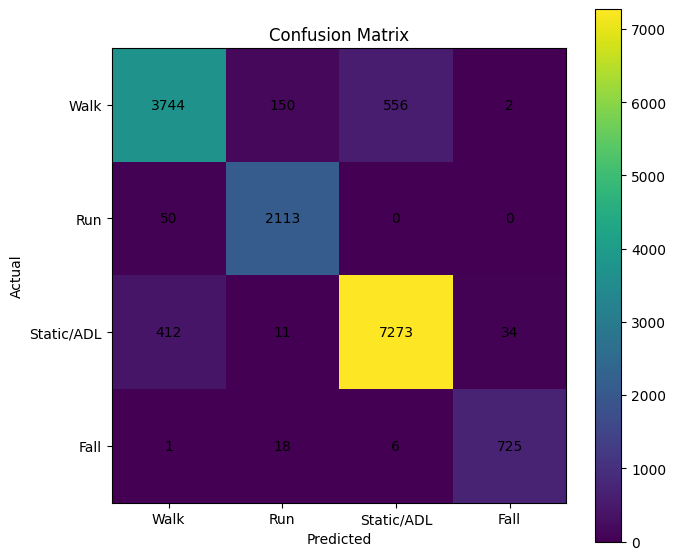

In [34]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(7, 6)
)

image = ax.imshow(cm)

ax.set_xticks(
    np.arange(NUM_CLASSES)
)

ax.set_yticks(
    np.arange(NUM_CLASSES)
)

ax.set_xticklabels(CLASS_NAMES)
ax.set_yticklabels(CLASS_NAMES)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

ax.set_title(
    "Confusion Matrix"
)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )

fig.colorbar(
    image,
    ax=ax
)

plt.tight_layout()
plt.show()

In [35]:
FINAL_MODEL = (
    "/content/drive/MyDrive/"
    "exo_fall_detector_v4.keras"
)

TFLITE_MODEL = (
    "/content/drive/MyDrive/"
    "exo_fall_detector_v4.tflite"
)


best_model.save(
    FINAL_MODEL
)

print(
    "Đã lưu Keras model:",
    FINAL_MODEL
)

Đã lưu Keras model: /content/drive/MyDrive/exo_fall_detector_v4.keras


In [38]:
import tensorflow as tf
import numpy as np

CHECKPOINT = "/content/drive/MyDrive/best_model_har.keras"

best_model = tf.keras.models.load_model(CHECKPOINT)

print("Loaded:", CHECKPOINT)
print("Input :", best_model.input_shape)
print("Output:", best_model.output_shape)

Loaded: /content/drive/MyDrive/best_model_har.keras
Input : (None, 200, 6)
Output: (None, 4)


In [39]:
from tensorflow.keras import Sequential, regularizers
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    BatchNormalization,
    MaxPooling1D,
    Dropout,
    LSTM,
    Dense,
)


def build_tflite_model(
    input_shape=(200, 6),
    num_classes=4
):
    model = Sequential([
        Input(shape=input_shape),

        # CNN 1
        Conv1D(
            32,
            kernel_size=3,
            padding="same",
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001)
        ),
        BatchNormalization(),

        # CNN 2
        Conv1D(
            32,
            kernel_size=3,
            padding="same",
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001)
        ),
        BatchNormalization(),

        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # LSTM 1
        LSTM(
            64,
            return_sequences=True,
            kernel_regularizer=regularizers.l2(0.001),

            # QUAN TRỌNG
            use_cudnn=False
        ),

        # LSTM 2
        LSTM(
            32,
            kernel_regularizer=regularizers.l2(0.001),

            # QUAN TRỌNG
            use_cudnn=False
        ),

        Dropout(0.4),

        Dense(
            16,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001)
        ),

        Dense(
            num_classes,
            activation="softmax"
        )
    ])

    return model

In [40]:
tflite_ready_model = build_tflite_model(
    input_shape=(200, 6),
    num_classes=4
)

# Build weights
dummy_input = np.zeros(
    (1, 200, 6),
    dtype=np.float32
)

_ = tflite_ready_model(
    dummy_input,
    training=False
)

tflite_ready_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 200, 32)        │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 200, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 200, 32)        │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 200, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,812 (163.33 KB)

 Trainable params: 41,684 (162.83 KB)

 Non-trainable params: 128 (512.00 B)

In [41]:
old_weights = best_model.get_weights()
new_weights = tflite_ready_model.get_weights()

print("Old weight arrays:", len(old_weights))
print("New weight arrays:", len(new_weights))

assert len(old_weights) == len(new_weights), (
    "Số lượng weight không giống nhau"
)

for i, (old_w, new_w) in enumerate(
    zip(old_weights, new_weights)
):
    print(
        i,
        old_w.shape,
        new_w.shape
    )

    assert old_w.shape == new_w.shape, (
        f"Weight {i} khác shape: "
        f"{old_w.shape} != {new_w.shape}"
    )

print("\nWeights hoàn toàn tương thích.")

Old weight arrays: 22
New weight arrays: 22
0 (3, 6, 32) (3, 6, 32)
1 (32,) (32,)
2 (32,) (32,)
3 (32,) (32,)
4 (32,) (32,)
5 (32,) (32,)
6 (3, 32, 32) (3, 32, 32)
7 (32,) (32,)
8 (32,) (32,)
9 (32,) (32,)
10 (32,) (32,)
11 (32,) (32,)
12 (32, 256) (32, 256)
13 (64, 256) (64, 256)
14 (256,) (256,)
15 (64, 128) (64, 128)
16 (32, 128) (32, 128)
17 (128,) (128,)
18 (32, 16) (32, 16)
19 (16,) (16,)
20 (16, 4) (16, 4)
21 (4,) (4,)

Weights hoàn toàn tương thích.


In [42]:
tflite_ready_model.set_weights(
    best_model.get_weights()
)

print("Đã copy toàn bộ trained weights.")

Đã copy toàn bộ trained weights.


In [43]:
sample_X = X_test[:64].astype(
    np.float32
)

old_output = best_model(
    sample_X,
    training=False
).numpy()

new_output = tflite_ready_model(
    sample_X,
    training=False
).numpy()


max_diff = np.max(
    np.abs(
        old_output - new_output
    )
)

mean_diff = np.mean(
    np.abs(
        old_output - new_output
    )
)

old_class = np.argmax(
    old_output,
    axis=1
)

new_class = np.argmax(
    new_output,
    axis=1
)

same_prediction = np.mean(
    old_class == new_class
)


print("Max difference :", max_diff)
print("Mean difference:", mean_diff)

print(
    "Same predicted class:",
    f"{same_prediction * 100:.2f}%"
)

Max difference : 3.5762787e-07
Mean difference: 1.2016166e-08
Same predicted class: 100.00%


In [46]:
import tensorflow as tf
import numpy as np

from tensorflow.keras import Sequential, regularizers
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    BatchNormalization,
    MaxPooling1D,
    Dropout,
    LSTM,
    Dense,
)


def build_tflite_export_model():
    model = Sequential([
        # Batch cố định = 1 phù hợp inference edge
        Input(
            batch_shape=(1, 200, 6),
            dtype=tf.float32
        ),

        Conv1D(
            32,
            3,
            padding="same",
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001)
        ),

        BatchNormalization(),

        Conv1D(
            32,
            3,
            padding="same",
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001)
        ),

        BatchNormalization(),

        MaxPooling1D(
            pool_size=2
        ),

        Dropout(0.3),

        # --------------------------------------------------
        # QUAN TRỌNG:
        # - không dùng cuDNN
        # - không tạo symbolic TensorList loop
        # --------------------------------------------------

        LSTM(
            64,
            return_sequences=True,
            use_cudnn=False,
            unroll=True,
            kernel_regularizer=regularizers.l2(0.001)
        ),

        LSTM(
            32,
            use_cudnn=False,
            unroll=True,
            kernel_regularizer=regularizers.l2(0.001)
        ),

        Dropout(0.4),

        Dense(
            16,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001)
        ),

        Dense(
            4,
            activation="softmax"
        )
    ])

    return model


export_model = build_tflite_export_model()

export_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (1, 200, 32)           │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (1, 200, 32)           │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (1, 200, 32)           │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (1, 200, 32)           │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (1, 100, 32)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (1, 100, 32)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (1, 100, 64)           │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (1, 32)                │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (1, 32)                │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (1, 16)                │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (1, 4)                 │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,812 (163.33 KB)

 Trainable params: 41,684 (162.83 KB)

 Non-trainable params: 128 (512.00 B)

In [47]:
export_model.set_weights(
    best_model.get_weights()
)

print("Đã copy trained weights.")

Đã copy trained weights.


In [48]:
CHECKPOINT = "/content/drive/MyDrive/best_model_har.keras"

best_model = tf.keras.models.load_model(
    CHECKPOINT
)

export_model.set_weights(
    best_model.get_weights()
)

print("Đã load checkpoint và copy weights.")

Đã load checkpoint và copy weights.


In [49]:
sample = X_test[0:1].astype(
    np.float32
)

old_output = best_model(
    sample,
    training=False
).numpy()

new_output = export_model(
    sample,
    training=False
).numpy()

print("Old:")
print(old_output)

print("\nExport:")
print(new_output)

print(
    "\nMax difference:",
    np.max(
        np.abs(
            old_output - new_output
        )
    )
)

print(
    "Old class   :",
    np.argmax(old_output)
)

print(
    "Export class:",
    np.argmax(new_output)
)

Old:
[[0.3602443  0.00156455 0.63693357 0.00125759]]

Export:
[[0.3602443  0.00156455 0.63693357 0.00125759]]

Max difference: 6.9849193e-10
Old class   : 2
Export class: 2


In [50]:
np.testing.assert_allclose(
    old_output,
    new_output,
    rtol=1e-4,
    atol=1e-4
)

print("Output giống nhau.")

Output giống nhau.


In [51]:
converter = tf.lite.TFLiteConverter.from_keras_model(
    export_model
)

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS
]

tflite_model = converter.convert()

print("TFLite conversion thành công!")

Saved artifact at '/tmp/tmpvo7f1v7g'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 200, 6), dtype=tf.float32, name='keras_tensor_156')
Output Type:
  TensorSpec(shape=(1, 4), dtype=tf.float32, name=None)
Captures:
  140050125970832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140050125971408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140050125968720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140050125972176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140050125972944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140050125970064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140050125969680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140050125971792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140050125971984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140050125972368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140050125974672: Tens

In [52]:
from pathlib import Path

TFLITE_MODEL = Path(
    "/content/drive/MyDrive/"
    "exo_fall_detector_v4.tflite"
)

with open(TFLITE_MODEL, "wb") as f:
    f.write(tflite_model)

size_mb = (
    TFLITE_MODEL.stat().st_size
    / 1024
    / 1024
)

print("Saved:", TFLITE_MODEL)
print(f"Size : {size_mb:.2f} MB")

Saved: /content/drive/MyDrive/exo_fall_detector_v4.tflite
Size : 0.67 MB


In [53]:
interpreter = tf.lite.Interpreter(
    model_path=str(TFLITE_MODEL)
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("INPUT:")
print(
    "shape:",
    input_details[0]["shape"],
    "dtype:",
    input_details[0]["dtype"]
)

print("\nOUTPUT:")
print(
    "shape:",
    output_details[0]["shape"],
    "dtype:",
    output_details[0]["dtype"]
)

INPUT:
shape: [  1 200   6] dtype: <class 'numpy.float32'>

OUTPUT:
shape: [1 4] dtype: <class 'numpy.float32'>


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [54]:
sample = X_test[0:1].astype(
    np.float32
)

# Keras
keras_output = export_model(
    sample,
    training=False
).numpy()

# TFLite
interpreter.set_tensor(
    input_details[0]["index"],
    sample
)

interpreter.invoke()

tflite_output = interpreter.get_tensor(
    output_details[0]["index"]
)

print("Keras:")
print(keras_output)

print("\nTFLite:")
print(tflite_output)

print(
    "\nKeras class:",
    np.argmax(keras_output)
)

print(
    "TFLite class:",
    np.argmax(tflite_output)
)

print(
    "Max diff:",
    np.max(
        np.abs(
            keras_output - tflite_output
        )
    )
)

Keras:
[[0.3602443  0.00156455 0.63693357 0.00125759]]

TFLite:
[[0.36024448 0.00156455 0.63693345 0.00125759]]

Keras class: 2
TFLite class: 2
Max diff: 1.7881393e-07


In [55]:
print("\n==============================")
print("TRAINING COMPLETED")
print("==============================")

print("Keras :")
print(FINAL_MODEL)

print("\nTFLite:")
print(TFLITE_MODEL)


TRAINING COMPLETED
Keras :
/content/drive/MyDrive/exo_fall_detector_v4.keras

TFLite:
/content/drive/MyDrive/exo_fall_detector_v4.tflite


In [56]:
from pathlib import Path

paths = [
    Path("/content/drive/MyDrive/best_model_har.keras"),
    Path("/content/drive/MyDrive/exo_fall_detector_v4.keras"),
    Path("/content/drive/MyDrive/exo_fall_detector_v4.tflite"),
]

for p in paths:
    print(p, "=>", p.exists())

/content/drive/MyDrive/best_model_har.keras => True
/content/drive/MyDrive/exo_fall_detector_v4.keras => True
/content/drive/MyDrive/exo_fall_detector_v4.tflite => True


In [57]:
from pathlib import Path
import zipfile

MODEL_FILES = [
    Path("/content/drive/MyDrive/best_model_har.keras"),
    Path("/content/drive/MyDrive/exo_fall_detector_v4.keras"),
    Path("/content/drive/MyDrive/exo_fall_detector_v4.tflite"),
]

ZIP_PATH = Path("/content/sisfall_models.zip")

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for file_path in MODEL_FILES:
        if file_path.exists():
            zf.write(
                file_path,
                arcname=file_path.name
            )
            print("Đã thêm:", file_path.name)
        else:
            print("Không tồn tại:", file_path)

print("\nZIP:", ZIP_PATH)
print(f"Size: {ZIP_PATH.stat().st_size / 1024 / 1024:.2f} MB")

Đã thêm: best_model_har.keras
Đã thêm: exo_fall_detector_v4.keras
Đã thêm: exo_fall_detector_v4.tflite

ZIP: /content/sisfall_models.zip
Size: 1.16 MB


In [58]:
from google.colab import files

files.download("/content/sisfall_models.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>